In [1]:
import os

REPO_PATH = '/content/code'
REPO_URL = 'https://github.com/Laio95/aml-2025-mistake-detection.git'

if os.path.exists(REPO_PATH):
    print(f"Repository found in {REPO_PATH}. Updating...")
    %cd {REPO_PATH}
    !git pull
    !git submodule update --init --recursive
else:
    print(f"Cloning repository into {REPO_PATH}...")
    !git clone --recursive {REPO_URL} {REPO_PATH}

%cd {REPO_PATH}

Cloning repository into /content/code...
Cloning into '/content/code'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 621 (delta 152), reused 166 (delta 134), pack-reused 415 (from 2)
Receiving objects: 100% (621/621), 4.97 MiB | 6.64 MiB/s, done.
Resolving deltas: 100% (385/385), done.
Submodule 'actionformer_release' (https://github.com/rohithpeddi/actionformer_release.git) registered for path 'actionformer_release'
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/actionformer_release'...
remote: Enumerating objects: 410, done.        
remote: Counting objects: 100% (26/26), done.        
remote: Compressing objects: 100% (20/20), done.        
remote: Total 410 (delta 16), reused 6 (delta 6), pack-reused 384 (from 2)        
Receiving objects: 100% (410/410), 651.07 KiB | 8.57 MiB/s, done.
Resolv

version

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# 1. Installazione dipendenze base
!pip install -r /content/code/requirements.txt
!pip install PyYAML pandas h5py joblib tensorboard ninja pytorchvideo

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
     ━━━━━━━━━━━━━━━━━

In [4]:
# 2. Compilazione C++ extension per NMS
import os
import sys

# --- NUOVO PERCORSO SUBMODULE ---
# Assumendo che actionformer sia un submodule dentro /content/code
SUBMODULE_PATH = "/content/code/actionformer_release"
UTILS_PATH = os.path.join(SUBMODULE_PATH, "libs/utils")

if not os.path.exists(UTILS_PATH):
    print(f"❌ Errore: Non trovo la cartella {UTILS_PATH}. Verifica la posizione del submodule!")
else:
    %cd {UTILS_PATH}

    # Pulizia profonda
    !rm -rf build/
    !rm -f nms_1d_cpu*.so
    !rm -f nms_1d_cuda*.so

    # Compilazione INPLACE
    !python setup.py build_ext --inplace

    # 3. Verifica immediata
    print("\n--- Controllo file compilati ---")
    compiled_files = [f for f in os.listdir('.') if f.endswith('.so')]
    if compiled_files:
        for f in compiled_files:
            print(f"✅ Trovato: {f}")
    else:
        print("❌ Errore: File .so non generati. Controlla i log sopra per errori di compilazione.")

# 4. AGGIORNAMENTO PYTHONPATH (Fondamentale)
# Aggiungiamo sia la root del codice che la cartella utils
os.environ['PYTHONPATH'] = f"/content/code:{UTILS_PATH}:" + os.environ.get('PYTHONPATH', '')

# Torniamo alla cartella dello step1
%cd /content/code/extension/step1

/content/code/actionformer_release/libs/utils
running build_ext
building 'nms_1d_cpu' extension
creating /content/code/actionformer_release/libs/utils/build/temp.linux-x86_64-cpython-312/csrc
[1/1] c++ -MMD -MF /content/code/actionformer_release/libs/utils/build/temp.linux-x86_64-cpython-312/csrc/nms_cpu.o.d -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/local/lib/python3.12/dist-packages/torch/include -I/usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -I/usr/include/python3.12 -c -c /content/code/actionformer_release/libs/utils/csrc/nms_cpu.cpp -o /content/code/actionformer_release/libs/utils/build/temp.linux-x86_64-cpython-312/csrc/nms_cpu.o -fopenmp -DTORCH_API_INCLUDE_EXTENSION_H -DTORCH_EXTENSION_NAME=nms_1d_cpu -std=c++17
creating build/lib.linux-x86_64-cpython-312
x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-

In [ ]:
%cd /content/code/extension/step1

!python train.py captaincook_egovlp.yaml \
    --backbone egovlp \
    --division_type recordings \
    --num_frames 90 \
    --output reproduce \
    #--feat_folder '/content/drive/MyDrive/AML_Project/CaptainCook4D/features_egovlp_num_frames_16' \


/content/code/extension/step1
2026-05-02 08:42:45.294641: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
{'dataset': {'backbone': 'egovlp',
             'crop_ratio': [0.9, 1.0],
             'default_fps': 29.97,
             'division_type': 'recordings',
             'downsample_rate': 1,
             'feat_folder': '/content/drive/MyDrive/AML_Project/CaptainCook4D/features_egovlp_num_frames_16',
             'feat_stride': 30,
             'file_ext': '.npz',
             'file_prefix': None,
             'file_suffix': '_360p',
             'force_upsampling': False,
             'input_dim': 256,
             'json_file': 'combined_recordings.json',
             'max_seq_len': 4096,
             'num_classes': 353,
             'num_frames

In [6]:
import os

# 1. Definiamo i percorsi
# Usa il file YAML che hai usato per il training
CONFIG_FILE = "captaincook_egovlp.yaml"

# Il percorso della cartella dove hai salvato i checkpoint
CHECKPOINT_DIR = "/content/drive/MyDrive/AML_Project/step1/checkpoints"

# Troviamo l'ultimo checkpoint generato (o quello che desideri testare)
# Se vuoi testare l'ultimo:
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "epoch_021.pth.tar")

# 2. Navighiamo nella cartella corretta
%cd /content/code/extension/step1

# 3. Lanciamo l'eval
# Nota: usiamo lo split 'test' come definito nel tuo YAML
%cd /content/code/extension/step1

# Se nel training avevi usato --output reproduce
!python eval.py captaincook_egovlp.yaml reproduce \
  --backbone egovlp \
  --saveonly \
  --all_splits

/content/code/extension/step1
/content/code/extension/step1
Checkpoint base path: /content/drive/MyDrive/AML_Project/step1/checkpoints/captaincook_dataset/egovlp_recordings_reproduce
{'dataset': {'backbone': 'egovlp',
             'crop_ratio': [0.9, 1.0],
             'default_fps': 29.97,
             'division_type': 'recordings',
             'downsample_rate': 1,
             'feat_folder': '/content/drive/MyDrive/AML_Project/CaptainCook4D/features_egovlp_num_frames_16',
             'feat_stride': 30,
             'file_ext': '.npz',
             'file_prefix': None,
             'file_suffix': '_360p',
             'force_upsampling': False,
             'input_dim': 256,
             'json_file': 'combined_recordings.json',
             'max_seq_len': 4096,
             'num_classes': 353,
             'num_frames': 30,
             'trunc_thresh': 0.3,
             'videos_type': 'all'},
 'dataset_name': 'captaincook_dataset',
 'devices': [0],
 'init_rand_seed': 1234567891,
 '

1. DISTRIBUZIONE SCORE
  Detection totali nel pkl: 768000
  score >= 0.001: 768000  (100.0%)
  score >= 0.010: 768000  (100.0%)
  score >= 0.050: 267986  (34.9%)
  score >= 0.100:  51777  (6.7%)
  score >= 0.200:   9702  (1.3%)
  score >= 0.500:   2433  (0.3%)


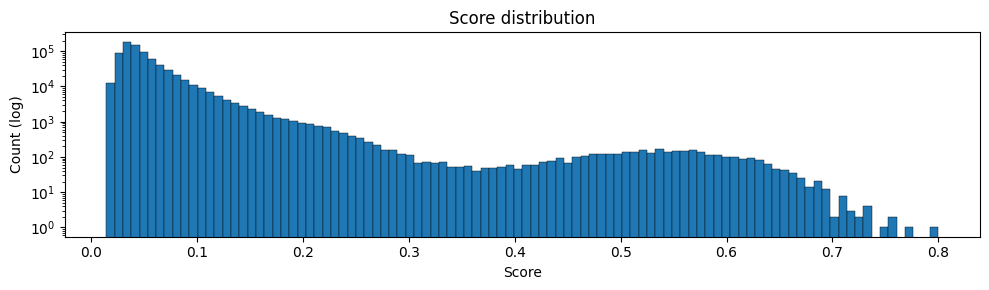


2. N_STEPS PREDETTI vs GROUND TRUTH
   Threshold |  Mean pred |  Mean GT |  Ratio
  -----------+------------+----------+-------
       0.001 |     2000.0 |     14.8 |  134.7x
       0.010 |     2000.0 |     14.8 |  134.7x
       0.050 |      697.9 |     14.8 |   47.0x
       0.100 |      134.8 |     14.8 |    9.1x
       0.200 |       25.3 |     14.8 |    1.7x

3. RECALL@0.5 A DIVERSI THRESHOLD
  score >= 0.001: Recall@0.5 = 0.9357
  score >= 0.010: Recall@0.5 = 0.9357
  score >= 0.050: Recall@0.5 = 0.9315
  score >= 0.100: Recall@0.5 = 0.9057
  score >= 0.200: Recall@0.5 = 0.7858

4. ISPEZIONE QUALITATIVA

Video: 1_19

Top-10 detection di ActionFormer (per score):
  [ 1] [  36.9s –   80.6s]  dur= 43.6s  score=0.6299  label_id=1
  [ 2] [ 166.5s –  275.7s]  dur=109.2s  score=0.6137  label_id=12
  [ 3] [ 103.2s –  152.2s]  dur= 49.0s  score=0.5902  label_id=4
  [ 4] [ 492.8s –  560.1s]  dur= 67.3s  score=0.5860  label_id=5
  [ 5] [ 280.4s –  309.9s]  dur= 29.5s  score=0.5829  label_id=9

In [9]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
PKL_PATH    = '/content/drive/MyDrive/AML_Project/step1/checkpoints/captaincook_dataset/egovlp_recordings_reproduce/eval_results.pkl'
STEP_EMB_DIR = '/content/drive/MyDrive/AML_Project/step1/step_embeddings'
GT_JSON     = '/content/code/extension/step1/combined_recordings.json'

# ─────────────────────────────────────────────────────────────────────────────
# 1. DISTRIBUZIONE DEGLI SCORE
#    Se il modello è ben addestrato, ci aspettiamo pochi proposal ad alto score
#    e molti a basso score (distribuzione a coda lunga).
#    Se invece vediamo tutto concentrato vicino a 0.001, il modello non discrimina.
# ─────────────────────────────────────────────────────────────────────────────
with open(PKL_PATH, 'rb') as f:
    raw = pickle.load(f)

scores = np.array(raw['score'])
print("=" * 55)
print("1. DISTRIBUZIONE SCORE")
print("=" * 55)
print(f"  Detection totali nel pkl: {len(scores)}")
for thr in [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]:
    n = (scores >= thr).sum()
    print(f"  score >= {thr:.3f}: {n:6d}  ({100*n/len(scores):.1f}%)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(scores, bins=100, log=True, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Score'); ax.set_ylabel('Count (log)'); ax.set_title('Score distribution')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2. CONFRONTO N_STEPS PREDETTI vs GROUND TRUTH
#    Per ogni video: quanti step ha la GT vs quanti ne predice ActionFormer
#    a diversi threshold.
# ─────────────────────────────────────────────────────────────────────────────
with open(GT_JSON) as f:
    gt_db = json.load(f)['database']

# Raggruppa detection per video
dets_by_video = {}
for vid, ts, te, lab, sc in zip(
    raw['video-id'], raw['t-start'], raw['t-end'], raw['label'], raw['score']
):
    dets_by_video.setdefault(str(vid), []).append({
        't_start': float(ts), 't_end': float(te),
        'label_id': int(lab), 'score': float(sc)
    })

print("\n" + "=" * 55)
print("2. N_STEPS PREDETTI vs GROUND TRUTH")
print("=" * 55)

gt_counts, pred_counts = {}, {}
for vid_id, info in gt_db.items():
    gt_counts[vid_id] = len(info.get('annotations', []))

thresholds = [0.001, 0.01, 0.05, 0.1, 0.2]
print(f"  {'Threshold':>10} | {'Mean pred':>10} | {'Mean GT':>8} | {'Ratio':>6}")
print(f"  {'-'*10}-+-{'-'*10}-+-{'-'*8}-+-{'-'*6}")
for thr in thresholds:
    preds = [
        sum(1 for d in dets if d['score'] >= thr)
        for vid, dets in dets_by_video.items()
    ]
    mean_pred = np.mean(preds)
    mean_gt   = np.mean([gt_counts.get(v, 0) for v in dets_by_video])
    print(f"  {thr:>10.3f} | {mean_pred:>10.1f} | {mean_gt:>8.1f} | {mean_pred/mean_gt:>6.1f}x")

# ─────────────────────────────────────────────────────────────────────────────
# 3. CALCOLO tIoU vs GROUND TRUTH
#    Per ogni video, per ogni step GT, trova la detection con tIoU più alta.
#    Recall@0.5: frazione di step GT coperti con tIoU >= 0.5
# ─────────────────────────────────────────────────────────────────────────────
def tiou(a, b):
    inter = max(0.0, min(a[1], b[1]) - max(a[0], b[0]))
    if inter == 0: return 0.0
    union = (a[1]-a[0]) + (b[1]-b[0]) - inter
    return inter / union if union > 0 else 0.0

print("\n" + "=" * 55)
print("3. RECALL@0.5 A DIVERSI THRESHOLD")
print("=" * 55)

for thr in thresholds:
    recalls = []
    for vid_id, info in gt_db.items():
        gt_anns = info.get('annotations', [])
        if not gt_anns or vid_id not in dets_by_video:
            continue
        dets_filtered = [d for d in dets_by_video[vid_id] if d['score'] >= thr]
        if not dets_filtered:
            recalls.append(0.0)
            continue
        pred_ivs = [(d['t_start'], d['t_end']) for d in dets_filtered]
        gt_ivs   = [(a['segment'][0], a['segment'][1]) for a in gt_anns]
        best = [max(tiou(g, p) for p in pred_ivs) for g in gt_ivs]
        recalls.append(np.mean(np.array(best) >= 0.5))
    print(f"  score >= {thr:.3f}: Recall@0.5 = {np.mean(recalls):.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. ISPEZIONE QUALITATIVA SU UN VIDEO
#    Confronta le top-10 detection (per score) con la GT di un video campione.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("4. ISPEZIONE QUALITATIVA")
print("=" * 55)

sample_vid = list(dets_by_video.keys())[0]
top_dets   = sorted(dets_by_video[sample_vid], key=lambda d: -d['score'])[:10]
gt_anns    = gt_db.get(sample_vid, {}).get('annotations', [])

print(f"\nVideo: {sample_vid}")
print(f"\nTop-10 detection di ActionFormer (per score):")
for i, d in enumerate(top_dets):
    dur = d['t_end'] - d['t_start']
    print(f"  [{i+1:2d}] [{d['t_start']:6.1f}s – {d['t_end']:6.1f}s]  "
          f"dur={dur:5.1f}s  score={d['score']:.4f}  label_id={d['label_id']}")

print(f"\nGround truth steps ({len(gt_anns)} totali):")
for i, a in enumerate(gt_anns):
    dur = a['segment'][1] - a['segment'][0]
    err = ' ← ERROR' if a.get('has_error') else ''
    print(f"  [{i+1:2d}] [{a['segment'][0]:6.1f}s – {a['segment'][1]:6.1f}s]  "
          f"dur={dur:5.1f}s  label='{a['label'][:35]}'{err}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. CHECK FINALE: il file .npz è integro?
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("5. INTEGRITÀ FILE .npz")
print("=" * 55)

npz_files = sorted(Path(STEP_EMB_DIR).glob('*.npz'))
print(f"  File .npz prodotti: {len(npz_files)}")
print(f"  File GT nel JSON:   {len(gt_db)}")
print(f"  Coverage:           {len(npz_files)/len(gt_db)*100:.1f}%")

sample_npz = np.load(npz_files[0], allow_pickle=True)
print(f"\n  Esempio: {npz_files[0].name}")
for key in sample_npz.files:
    arr = sample_npz[key]
    print(f"    {key}: shape={getattr(arr, 'shape', '(scalar)')}  dtype={getattr(arr, 'dtype', type(arr))}")

In [10]:
%cd /content/code/extension/step1

PKL_PATH    = '/content/drive/MyDrive/AML_Project/step1/checkpoints/captaincook_dataset/egovlp_recordings_reproduce/eval_results.pkl'
FEAT_FOLDER = '/content/drive/MyDrive/AML_Project/CaptainCook4D/features_egovlp_num_frames_16'
OUTPUT_DIR  = '/content/drive/MyDrive/AML_Project/step1/step_embeddings'

!python build_step_embeddings.py \
    --pkl        "{PKL_PATH}" \
    --feat_folder "{FEAT_FOLDER}" \
    --output_dir  "{OUTPUT_DIR}" \
    --file_suffix "_360p" \
    --file_ext    ".npz" \
    --score_threshold 0.1 \
    --verify

/content/code/extension/step1
Loaded 51777/768000 detections (score >= 0.1) across 384 videos.
  [50/384] 16_26: 195 steps → 16_26_step_embeddings.npz
  [100/384] 22_4: 188 steps → 22_4_step_embeddings.npz
  [150/384] 28_26: 124 steps → 28_26_step_embeddings.npz
  [200/384] 8_33: 37 steps → 8_33_step_embeddings.npz
  [250/384] 26_19: 197 steps → 26_19_step_embeddings.npz
  [300/384] 16_42: 160 steps → 16_42_step_embeddings.npz
  [350/384] 28_24: 156 steps → 28_24_step_embeddings.npz
  [384/384] 9_108: 103 steps → 9_108_step_embeddings.npz

Done. Saved 384/384 step embedding files in '/content/drive/MyDrive/AML_Project/step1/step_embeddings'.

Verification (3 samples):
  10_16_step_embeddings.npz
    step_embeddings : (193, 256)  (mean norm: 25.149)
    step_intervals  : (193, 2)  (t range: [1.5s – 965.5s])
  10_18_step_embeddings.npz
    step_embeddings : (107, 256)  (mean norm: 25.028)
    step_intervals  : (107, 2)  (t range: [0.6s – 620.2s])
  10_24_step_embeddings.npz
    step_embe